In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [2]:
file_list = ["/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_sae_final_rfs.npy", "/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_pca-ae_final_rfs.npy", "/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy"]  

# Loop through each file, load it, and show its shape
for file_name in file_list:
    data = np.load(file_name)
    print(f"{file_name}: shape = {data.shape}")

/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_sae_final_rfs.npy: shape = (10, 128, 3, 32, 32)
/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_pca-ae_final_rfs.npy: shape = (10, 128, 3, 32, 32)
/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy: shape = (10, 128, 3, 32, 32)


In [3]:
# --- Jensen-Shannon divergence across 3 distributions ---
def js_divergence_multi(dists, base=np.e):
    """
    Compute Jensen-Shannon divergence among N distributions.
    dists: list or array of shape (N, bins)
    Returns scalar JSD.
    """
    dists = np.asarray(dists, dtype=np.float64)
    eps = 1e-12
    dists = dists + eps
    dists = dists / dists.sum(axis=1, keepdims=True)  # normalize each
    M = np.mean(dists, axis=0)
    H_M = entropy(M, base=base)
    H_P = np.mean([entropy(p, base=base) for p in dists])
    return H_M - H_P

# --- Compute JSD for selected receptive field range ---
def compute_rgb_jsd_multi(model_data, rf_range, bins=50, hist_range=(0, 1)):
    """
    model_data: (128, 3, 32, 32)
    rf_range: Python range or list of receptive field indices to include
    """
    subset = model_data[rf_range, :, :, :]  # restrict receptive fields
    channels = [subset[:, c, :, :].ravel() for c in range(3)]
    hists = [np.histogram(ch, bins=bins, range=hist_range, density=True)[0] for ch in channels]
    return js_divergence_multi(hists)


/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_sae_final_rfs.npy: mean JSD = 0.0747 ± 0.0269


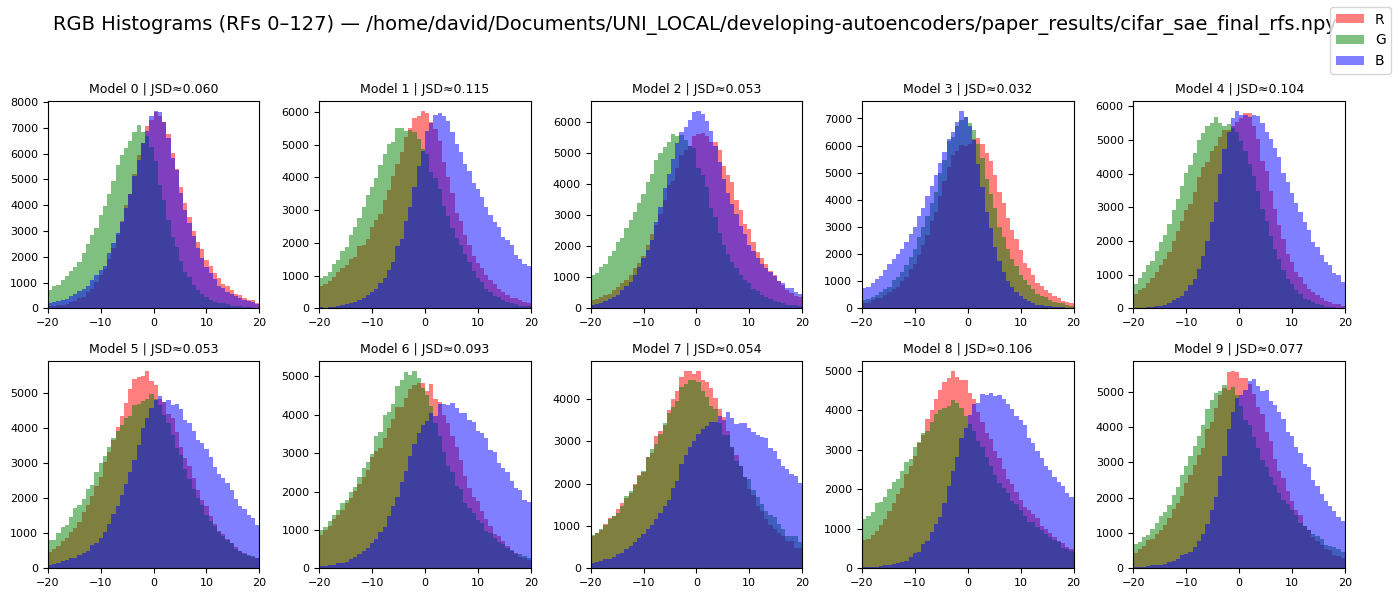

/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_pca-ae_final_rfs.npy: mean JSD = 0.0556 ± 0.0250


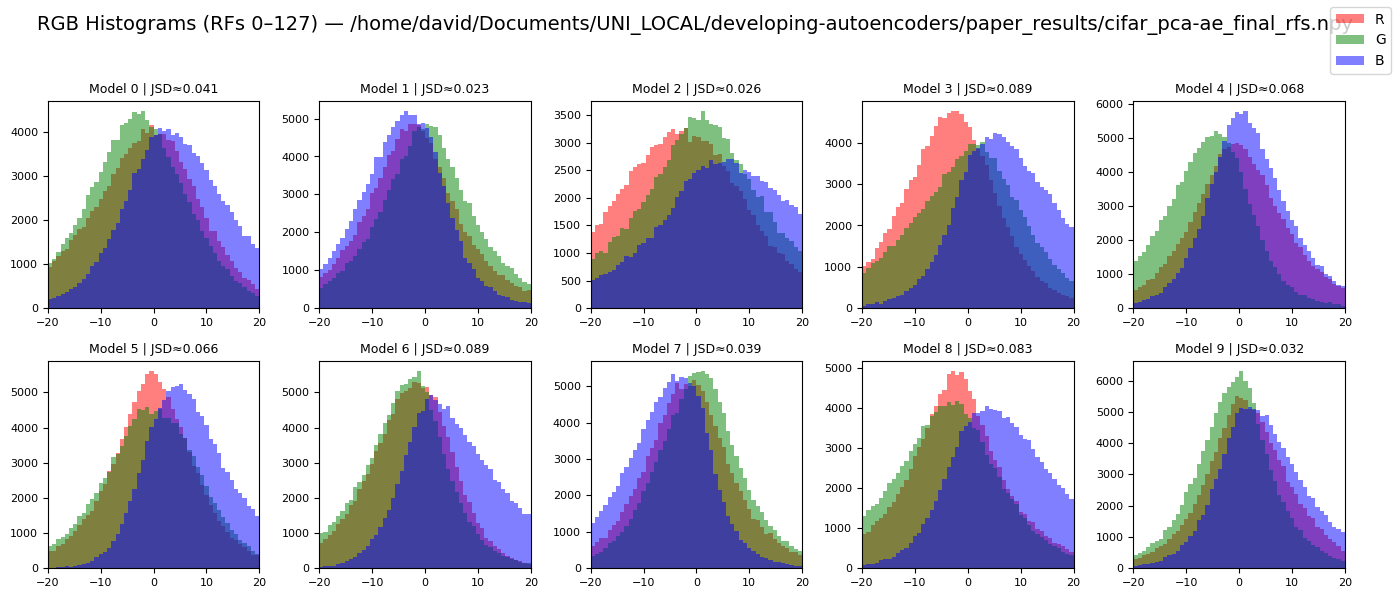

/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy: mean JSD = 0.0272 ± 0.0150


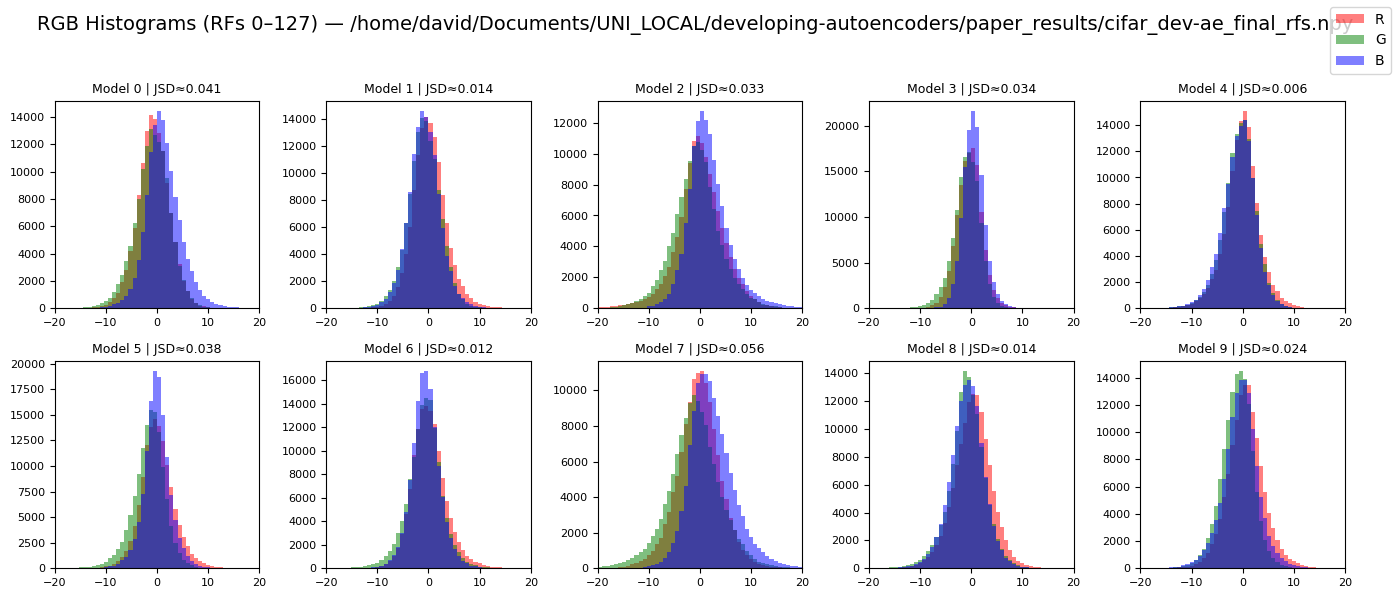

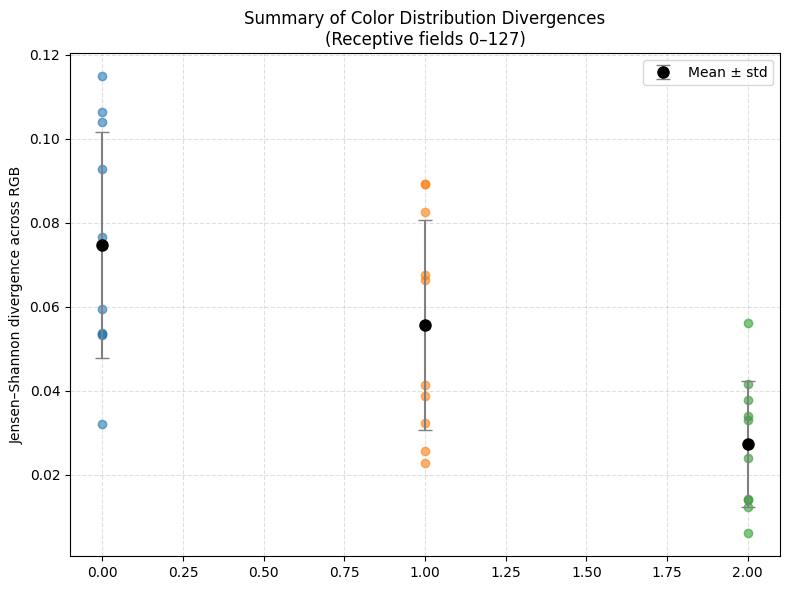

In [6]:
bins = 50
hist_range = (-20, 20)
rf_range = range(0, 128)   # <-- change this line to select different RFs
colors = ['red', 'green', 'blue']
channel_names = ['R', 'G', 'B']

# --- Collect summary stats ---
all_means, all_stds, all_jsd_values = [], [], []

for file_name in file_list:
    data = np.load(file_name)  # shape: (10, 128, 3, 32, 32)
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle(f"RGB Histograms (RFs {rf_range.start}–{rf_range.stop-1}) — {file_name}", fontsize=14)
    axes = axes.ravel()

    jsd_values = []

    for model_idx in range(10):
        ax = axes[model_idx]
        model_data = data[model_idx]

        # Plot histograms for the selected receptive field range
        subset = model_data[rf_range, :, :, :]
        for c, color in enumerate(colors):
            values = subset[:, c, :, :].ravel()
            ax.hist(values, bins=bins, range=hist_range, color=color, alpha=0.5, label=channel_names[c])

        jsd_mean = compute_rgb_jsd_multi(model_data, rf_range, bins=bins, hist_range=hist_range)
        jsd_values.append(jsd_mean)

        ax.set_title(f"Model {model_idx} | JSD≈{jsd_mean:.3f}", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.set_xlim(hist_range)

    jsd_values = np.array(jsd_values)
    mean_jsd, std_jsd = jsd_values.mean(), jsd_values.std()
    all_means.append(mean_jsd)
    all_stds.append(std_jsd)
    all_jsd_values.append(jsd_values)

    print(f"{file_name}: mean JSD = {mean_jsd:.4f} ± {std_jsd:.4f}")

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout(rect=[0, 0, 0.98, 0.95])
    plt.show()

np.save('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/jsd_results.npy', all_jsd_values)

# --- Summary comparison plot ---
plt.figure(figsize=(8, 6))
x_positions = np.arange(len(file_list))

# Scatter individual sub-models
for i, jsd_vals in enumerate(all_jsd_values):
    plt.scatter(np.full_like(jsd_vals, x_positions[i]), jsd_vals, alpha=0.6)

# Error bars for mean ± std
plt.errorbar(
    x_positions,
    all_means,
    yerr=all_stds,
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=5,
    markersize=8,
    label='Mean ± std'
)

plt.ylabel("Jensen–Shannon divergence across RGB")
plt.title(f"Summary of Color Distribution Divergences\n(Receptive fields {rf_range.start}–{rf_range.stop-1})")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
sae_rfs = np.load("/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_sae_final_rfs.npy")
pca_ae_rfs = np.load("/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_pca-ae_final_rfs.npy")
dev_ae_rfs = np.load("/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy")

/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy: mean JSD = 0.0872 ± 0.0277


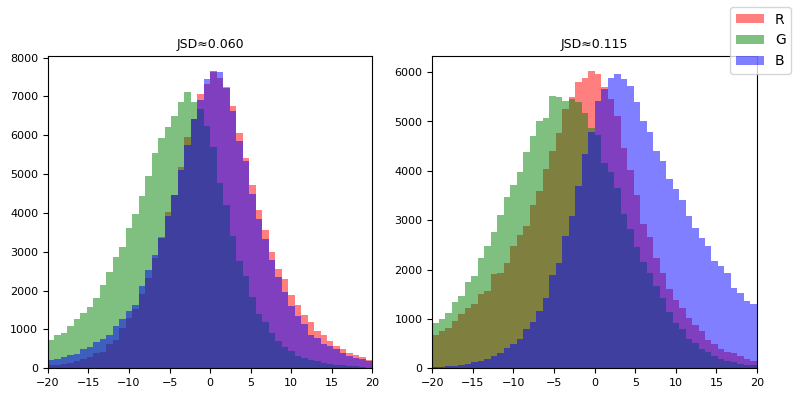

/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy: mean JSD = 0.0320 ± 0.0094


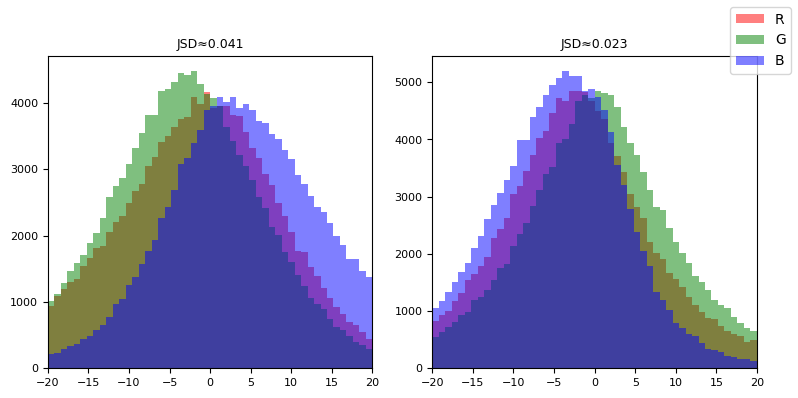

/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy: mean JSD = 0.0278 ± 0.0136


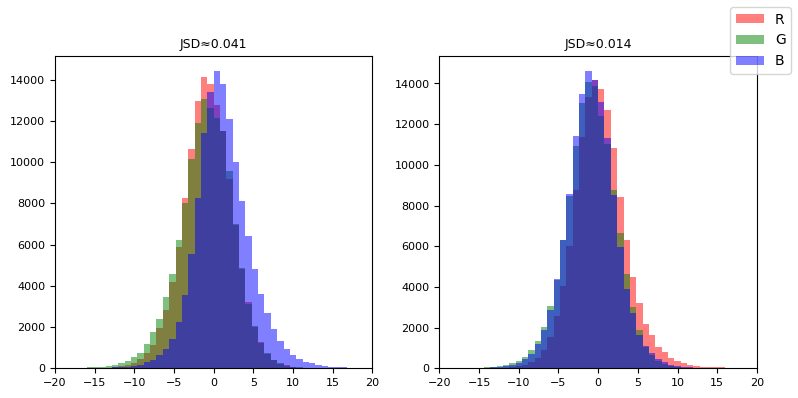

In [22]:
for model_rfs in [sae_rfs, pca_ae_rfs, dev_ae_rfs]:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes = axes.ravel()

    jsd_values = []

    for model_idx in range(2):
        ax = axes[model_idx]
        model_data = model_rfs[model_idx]

        # Plot histograms for the selected receptive field range
        subset = model_data[rf_range, :, :, :]
        for c, color in enumerate(colors):
            values = subset[:, c, :, :].ravel()
            ax.hist(values, bins=bins, range=hist_range, color=color, alpha=0.5, label=channel_names[c])

        jsd_mean = compute_rgb_jsd_multi(model_data, rf_range, bins=bins, hist_range=hist_range)
        jsd_values.append(jsd_mean)

        ax.set_title(f"JSD≈{jsd_mean:.3f}", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.set_xlim(hist_range)

    jsd_values = np.array(jsd_values)
    mean_jsd, std_jsd = jsd_values.mean(), jsd_values.std()

    print(f"{file_name}: mean JSD = {mean_jsd:.4f} ± {std_jsd:.4f}")

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout(rect=[0, 0, 0.98, 0.95])
    plt.show()


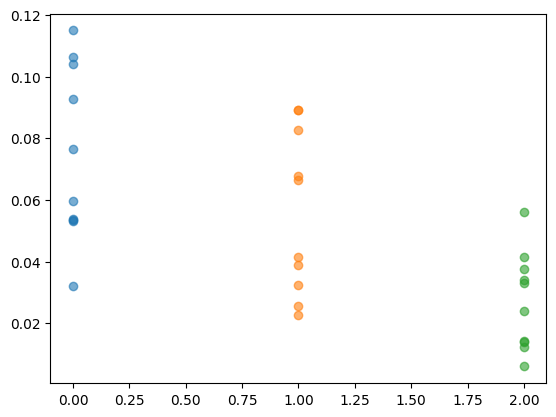

In [ ]:
jsd_values = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/jsd_results.npy')

# Reset the lists to avoid duplicating data
all_means, all_stds, all_jsd_values = [], [], []

for i in range(len(jsd_values)):
    mean_jsd, std_jsd = jsd_values[i].mean(), jsd_values[i].std()
    all_means.append(mean_jsd)
    all_stds.append(std_jsd)
    all_jsd_values.append(jsd_values[i])
    
    print(f"{file_list[i]}: mean JSD = {mean_jsd:.4f} ± {std_jsd:.4f}")

# Create summary comparison plot
plt.figure(figsize=(8, 6))
x_positions = np.arange(len(file_list))

# Scatter individual sub-models
for i, jsd_vals in enumerate(all_jsd_values):
    plt.scatter(np.full_like(jsd_vals, x_positions[i]), jsd_vals, alpha=0.6)

# Error bars for mean ± std
plt.errorbar(
    x_positions,
    all_means,
    yerr=all_stds,
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=5,
    markersize=8,
    label='Mean ± std'
)

plt.ylabel("Jensen–Shannon divergence across RGB")
plt.title(f"Summary of Color Distribution Divergences\n(Receptive fields {rf_range.start}–{rf_range.stop-1})")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
